<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Melbourne%20Housing%20Market/Melbourne_Housing_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Market

We have a set of data belonging to Melbourne housing market snapshot downloaded from Kaggle Website (https://www.kaggle.com/).


the data contains the following headers:

Suburb: Name of the suburb where the property is located.

Address: Full address of the property.

Rooms: Number of rooms in the property.

Type: Type of dwelling (e.g., house, townhouse, unit).

Price: Sale price of the property in Australian dollars.

Method: Method of sale (e.g., auction, private sale).

SellerG: Name of the real estate agent or agency.

Date: Date when the property was sold.

Distance: Distance of the property from Melbourne's Central Business District (CBD) in kilometers.

Postcode: Postal code of the property's location.

Bedroom: Number of bedrooms.

Bathroom: Number of bathrooms.

Car: Number of car parking spaces.

Landsize: Land size of the property in square meters.

BuildingArea: Building area of the property in square meters.

YearBuilt: Year the property was built.

CouncilArea: Governing council for the property's location.

Latitude: Latitude coordinate of the property.

Longitude: Longitude coordinate of the property.

Regionname: General region (e.g., Western Metropolitan, Southern Metropolitan) where the property is located.

Propertycount: Number of properties sold in the suburb.

## The task is:

1. Preprocessing the data and handle the null values

2. Visualizing general dependency of the price against colums "Type", "Method" and "Regionname"

3. Using as many features as possible to create a model for the price.

4. Evaluating the over-all goodness of the fit and error parameters.

5. Plotting the predicted and actual price distributions.

6. Predicting the prices of an unseen data with the following parameters.

new_house_data = {
    'Rooms': 3,
    'Type': 'h',  # 'h' for house
    'Distance': 12.1,
    'Method': 'S', # 'S' for sold
    'SellerG': 'Biggin',
    'Bedroom': 3,
    'Bathroom': 2,
    'Car': 2,
    'Landsize': 550.0,
    'BuildingArea': 150.0,
    'YearBuilt': 1980,
    'CouncilArea': 'Boroondara',
    'Regionname': 'Southern Metropolitan',
    'Propertycount': 7809,
    'Suburb': 'Kew',
    'Address': '123 Fake St'
}

# Data Preprocessing

In [ ]:
# __ importing required libraries and modules
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# I read the data through the following github repository:

url = "https://github.com/kuroshkarimi/Machine-Learning-and-Data-Analysis/raw/refs/heads/main/Melbourne%20Housing%20Market/melb_data.xlsx"
data = pd.read_excel(url)
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,2017-03-04,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,2016-06-04,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [ ]:
# __ Taking a glance at the overall information of the columns and rows
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13580 non-null  object        
 1   Address        13580 non-null  object        
 2   Rooms          13580 non-null  int64         
 3   Type           13580 non-null  object        
 4   Price          13580 non-null  int64         
 5   Method         13580 non-null  object        
 6   SellerG        13580 non-null  object        
 7   Date           13580 non-null  datetime64[ns]
 8   Distance       13580 non-null  float64       
 9   Postcode       13580 non-null  int64         
 10  Bedroom        13580 non-null  int64         
 11  Bathroom       13580 non-null  int64         
 12  Car            13518 non-null  float64       
 13  Landsize       13580 non-null  int64         
 14  BuildingArea   7130 non-null   float64       
 15  YearBuilt      8205

general information of this data indicates there are some columns with missing values.
These columns are the car parks, the building area, built year, and council area.

In [ ]:
# __ General statistics of the columns
data.describe(include='all')


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,2017-01-28 20:25:03.622974976,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,2016-01-28 00:00:00,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,2016-09-10 00:00:00,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,2017-03-04 00:00:00,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,2017-06-24 00:00:00,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000
max,NaN,NaN,10.000000,NaN,9.000000e+06,NaN,NaN,2017-09-23 00:00:00,48.100000,3977.000000,...,8.000000,10.000000,433014.000000,44515.000000,2018.000000,NaN,-37.408530,145.526350,NaN,21650.000000


In [ ]:
data.Date


,Date
0,2016-12-03
1,2016-02-04
2,2017-03-04
3,2017-03-04
4,2016-06-04
...,...
13575,2017-08-26
13576,2017-08-26
13577,2017-08-26
13578,2017-08-26


From the overall informational and statistical properties of this data set, we could conclude that we are dealing with data columns with the
following formats and characteristics:

1. Numerical columns

2. object columns with few categories:
    
    columns like Type, Method and Regionname, where the unique categories are limited and could be handled by OneHotEncoder.

3. object columns with many categories:

    there are high cardinal features (columns with many categories), such as Address, Suburb, SellerG, and CouncilArea,
   
    we are better to use category encoder which replaces the categories of a given feature with the average target value
   
    of the respective category (target encoder).


4. Date column with a time-date format:

    to make use of the Date column, we change its format from date-time to ordinal timestamp, the format of which is numeric.

In [ ]:
#! pip install seaborn

In [ ]:
# To get a better insight into the categorical data, we can visualize the average price for different
# categories of the Regionname, Method and Type columns. So, it could be seen that the price is
# in face correlated with categories in these object format columns

import seaborn as sns

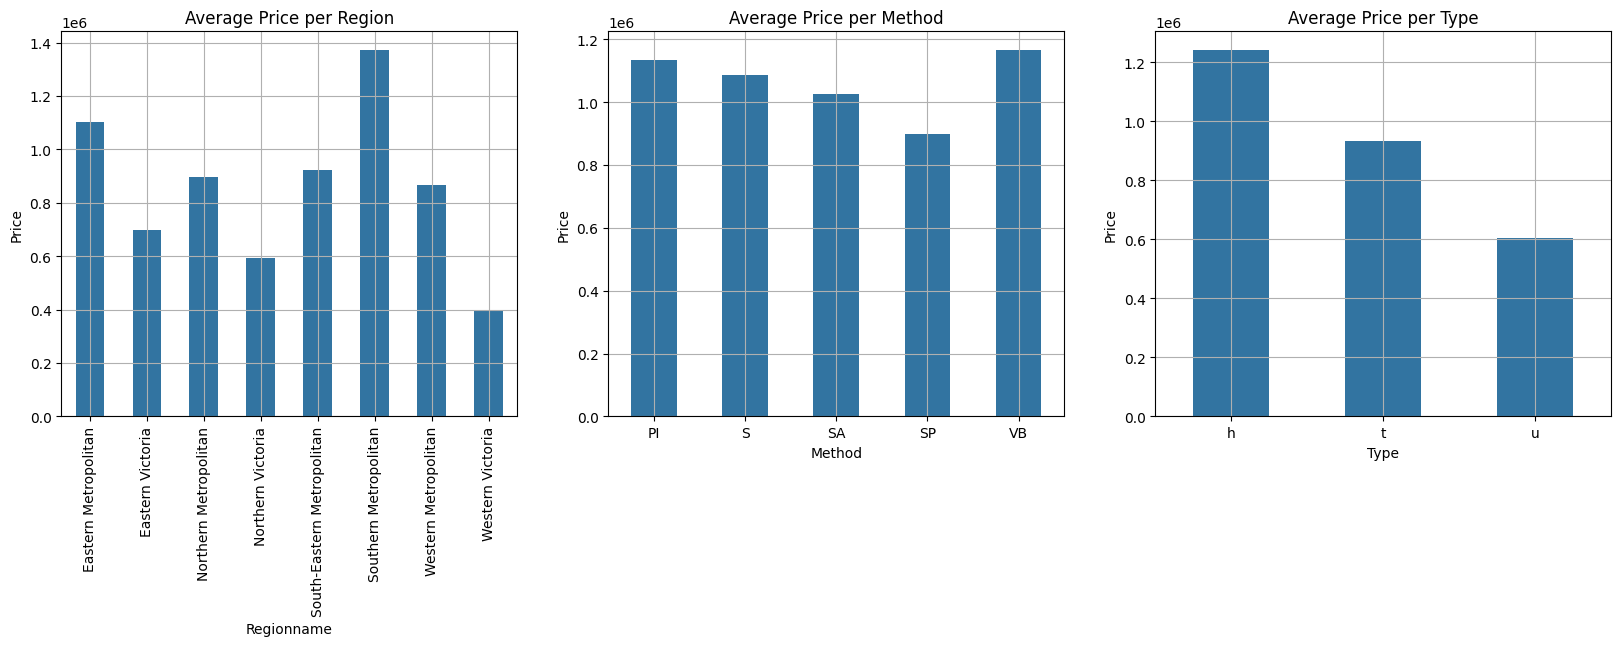

In [ ]:

price_region = data.groupby(['Regionname'])['Price'].mean().to_frame()
price_method = data.groupby(['Method'])['Price'].mean().to_frame()
price_type = data.groupby(['Type'])['Price'].mean().to_frame()

fig, ax = plt.subplots(1, 3, figsize = (20, 5))
sns.barplot(x='Regionname', y='Price', data=price_region, width = 0.5, ax=ax[0])
sns.barplot(x='Method', y='Price', data=price_method, width = 0.5, ax=ax[1])
sns.barplot(x='Type', y='Price', data=price_type, width = 0.5, ax=ax[2])
ax[0].tick_params(axis='x', rotation=90)
ax[0].grid()
ax[0].title.set_text('Average Price per Region')
ax[1].grid()
ax[1].title.set_text('Average Price per Method')
ax[2].grid()
ax[2].title.set_text('Average Price per Type')


In [ ]:
data['Date_ordinal'] = data['Date'].map(pd.Timestamp.toordinal)
data.drop('Date', axis=1, inplace=True)   # dropping the original Date columns with a data-time format

In [ ]:
# Handling the null values
# we can impute the numerical columns with their mean and the categorical column with their mode

from sklearn.impute import SimpleImputer
mean_impute = SimpleImputer(missing_values = np.nan, strategy = 'mean')
mode_impute = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')

data[['Car', 'BuildingArea', 'YearBuilt']] = mean_impute.fit_transform(data[['Car', 'BuildingArea', 'YearBuilt']])
data[['CouncilArea']] = mode_impute.fit_transform(data[['CouncilArea']])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  int64  
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Distance       13580 non-null  float64
 8   Postcode       13580 non-null  int64  
 9   Bedroom        13580 non-null  int64  
 10  Bathroom       13580 non-null  int64  
 11  Car            13580 non-null  float64
 12  Landsize       13580 non-null  int64  
 13  BuildingArea   13580 non-null  float64
 14  YearBuilt      13580 non-null  float64
 15  CouncilArea    13580 non-null  object 
 16  Latitude       13580 non-null  float64
 17  Longitude      13580 non-null  float64
 18  Region

In [ ]:
# Differentiating the feature columns from the target one

y = data['Price']

X = data.drop('Price', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer

# 3. Define column groups (same as before)
categorical_ohe_features = ['Type', 'Method', 'Regionname']
categorical_target_features = ['Address', 'Suburb', 'SellerG', 'CouncilArea']
numerical_features = ['Rooms', 'Distance', 'Bedroom', 'Bathroom', 'Car',
                     'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']

# 1. Ensure consistent data types in categorical columns
def clean_categoricals(df, cat_cols):
    df = df.copy()
    for col in cat_cols:
        # Convert booleans to strings if mixed with strings
        if df[col].dtype == 'object' and any(isinstance(x, bool) for x in df[col]):
            df[col] = df[col].astype(str)
        # Convert all to strings for consistency
        df[col] = df[col].astype(str)
    return df

# 2. Clean your data first
X_train_clean = clean_categoricals(X_train, categorical_ohe_features + categorical_target_features)



# 4. Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_ohe_features),
        ('target', TargetEncoder(target_type='continuous'), categorical_target_features)
    ],
    remainder='passthrough'
)

# 5. Fit and transform
X_train_transformed = preprocessor.fit_transform(X_train_clean, y_train)

# 6. Get feature names
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)

# For test data:
X_test_clean = clean_categoricals(X_test, categorical_ohe_features + categorical_target_features)
X_test_transformed = preprocessor.transform(X_test_clean)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

In [ ]:
X_test_transformed

,num__Rooms,num__Distance,num__Bedroom,num__Bathroom,num__Car,num__Landsize,num__BuildingArea,num__YearBuilt,num__Propertycount,ohe__Type_h,...,ohe__Regionname_Western Metropolitan,ohe__Regionname_Western Victoria,target__Address,target__Suburb,target__SellerG,target__CouncilArea,remainder__Postcode,remainder__Latitude,remainder__Longitude,remainder__Date_ordinal
0,1.100753,-0.361058,1.112331,0.671074,0.412246,-0.026439,0.085038,-1.937423,-0.251166,1.0,...,1.0,0.0,1.076087e+06,1.320130e+06,1.237942e+06,9.972965e+05,3016.0,-37.86100,144.89850,736455.0
1,-0.979000,-0.599098,-0.941785,-0.772599,-1.673703,-0.089872,-0.164882,-2.291108,-1.160188,1.0,...,1.0,0.0,1.076087e+06,9.756820e+05,1.015408e+06,8.117570e+05,3011.0,-37.81000,144.88960,736175.0
2,0.060876,0.064013,0.085273,-0.772599,-0.630728,0.003452,-0.002164,-0.003323,-0.747309,1.0,...,1.0,0.0,1.076087e+06,6.508651e+05,8.329847e+05,1.020585e+06,3020.0,-37.76740,144.82421,736588.0
3,0.060876,-0.956157,-0.941785,0.671074,-0.630728,-0.099912,-0.043361,1.245745,0.055511,0.0,...,0.0,0.0,1.018000e+06,1.087587e+06,1.919554e+06,1.302925e+06,3181.0,-37.85260,145.00710,736182.0
4,0.060876,-0.276044,0.085273,0.671074,0.412246,-0.019594,-0.002164,-0.003323,0.002296,1.0,...,0.0,0.0,1.076087e+06,7.870887e+05,1.000859e+06,1.020585e+06,3044.0,-37.72523,144.94567,736588.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2711,-0.979000,-0.633103,-0.941785,-0.772599,-0.630728,-0.118394,-0.270353,1.705536,0.021793,0.0,...,1.0,0.0,1.076087e+06,7.240869e+05,6.847301e+05,8.117570e+05,3011.0,-37.80140,144.89590,736392.0
2712,1.100753,-0.361058,1.112331,0.671074,2.498196,-0.003394,-0.002164,-0.003323,-0.251166,1.0,...,1.0,0.0,1.076087e+06,1.320130e+06,1.070611e+06,9.972965e+05,3016.0,-37.85790,144.87860,736462.0
2713,0.060876,0.115021,0.085273,-0.772599,-0.630728,0.043611,-0.002164,-0.003323,-0.686983,1.0,...,0.0,0.0,1.076087e+06,1.171628e+06,8.838769e+05,1.020585e+06,3105.0,-37.78094,145.10131,736560.0
2714,1.100753,-0.667109,1.112331,-0.772599,1.455221,-0.020050,-0.002090,-1.406895,-0.285114,1.0,...,1.0,0.0,1.076087e+06,1.101532e+06,1.353813e+06,9.845840e+05,3039.0,-37.76421,144.90571,736518.0


# Model Creation

In [ ]:
# Fitting the random forest model to the trained data
# and calculation of the r_squared

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error


rf_model = RandomForestRegressor(n_estimators = 100)
rf_model.fit(X_train_transformed, y_train)
y_rf = rf_model.predict(X_test_transformed)

print(f'r-squared score: {r2_score(y_test, y_rf):0.3f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_rf):0.3f}')
print(f'MAE: {mean_absolute_error(y_test, y_rf):0.3f}')

r-squared score: 0.831
RMSE: 258451.479
MAE: 157482.956


The 0.834 value of r-squared quantity shows that 0.834 of the housing price variance in the data could be
justified by this random forest model with the chosen features.

About 100 thousand Australian dollars difference between RMSE AND MAE implies the existence of outliers in the housing price data
this is because the outliers are weighed more than other price values due to the square power of the errors

# Distribution of Predicted vs Actual Prices

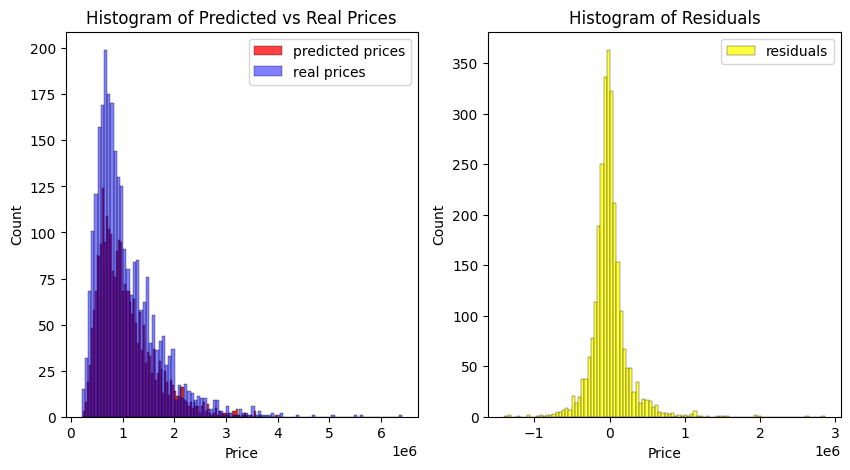

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
sns.histplot(y_rf, bins = 100, color='red', label = 'predicted prices', ax=ax[0])
sns.histplot(y_test, bins = 100, color='blue', label = 'real prices', alpha=0.5, ax=ax[0])

sns.histplot((y_test - y_rf), bins=100, color='yellow', label = 'residuals', ax = ax[1])
ax[0].set_title('Histogram of Predicted vs Real Prices')
ax[1].set_title('Histogram of Residuals')
ax[0].legend()
ax[1].legend()

left graph;

The general similarity between the predicted and actual prices shows that we are on the right track and the model is capturing the underlying distribution of the actual data. Additionally, the comparable width of distributions indicate the model is capturing the variability of the data as well.

.
.
.

right graph:

The normal distribution of the residuals with zero mean implies that the model is doing well in predicting the prices. This leads to the highest number of residual members with zero and close to zero magnitudes.

The narrowness of the standard deviation of the residual histogram shows the pretty high precession of the model which results from lower error values.

# Predicted Price of a New Data Vector  

In [ ]:
X_test.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Distance',
       'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
       'YearBuilt', 'CouncilArea', 'Latitude', 'Longitude', 'Regionname',
       'Propertycount', 'Date_ordinal'],
      dtype='object')

In [ ]:
# The new data vector is:

new_data = {


    'Suburb': 'Kew',
    'Address': '123 Fake St',
    'Rooms': 3,
    'Type': 'h',  # 'h' for house
    'Method': 'S', # 'S' for sold
    'SellerG': 'Biggin',
    'Distance': 12.1,
    'Postcode': 0 ,
    'Bedroom': 3,
    'Bathroom': 2,
    'Car': 2,
    'Landsize': 550.0,
    'BuildingArea': 150.0,
    'YearBuilt': 1980,
    'CouncilArea': 'Boroondara',
    'Latitude': 0,
    'Longitude': 0,
    'Regionname': 'Southern Metropolitan',
    'Propertycount': 7809,
    'Date_ordinal': 0
}

In [ ]:
X_new_clean = clean_categoricals((pd.DataFrame([new_data], columns = list(new_data.keys()))), categorical_ohe_features + categorical_target_features)
X_new_transformed = preprocessor.transform(X_new_clean)
y_new = rf_model.predict(X_new_transformed)
print(f'Considering the given features the new data, the predicted price is: {y_new[0]} $')

Considering the given features the new data, the predicted price is: 2189415.0 $


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
